In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Exercise 9-1
- A square $Q$ has the following equalities, demonstrate this in code by computing $Q$ from a random matrix and show for all 4 expressions the result is the identity matrix
$$
Q^T Q = Q Q^T = Q^{-1} Q = Q Q^{-1} = I
$$

In [2]:
A = np.random.default_rng().random((3, 3))
Q, _ = np.linalg.qr(A)
Q

array([[-0.09505288,  0.81263772, -0.57496512],
       [-0.527131  , -0.53104549, -0.66341811],
       [-0.84445122,  0.24002214,  0.47884393]])

In [3]:
Q.T @ Q

array([[ 1.00000000e+00, -2.70671966e-17, -3.66970121e-17],
       [-2.70671966e-17,  1.00000000e+00, -5.83901673e-17],
       [-3.66970121e-17, -5.83901673e-17,  1.00000000e+00]])

In [4]:
Q @ Q.T

array([[1.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.00000000e+00, 5.55111512e-17],
       [0.00000000e+00, 5.55111512e-17, 1.00000000e+00]])

In [5]:
np.linalg.inv(Q) @ Q

array([[ 1.00000000e+00,  2.95517196e-17, -3.43482169e-17],
       [ 5.00572500e-18,  1.00000000e+00,  2.42893608e-17],
       [-8.35734714e-17,  6.59560405e-17,  1.00000000e+00]])

In [6]:
Q @ np.linalg.inv(Q)

array([[ 1.00000000e+00, -1.33508949e-17, -4.49689486e-17],
       [-3.98167508e-17,  1.00000000e+00,  1.67871929e-17],
       [-1.54007678e-17,  5.59630914e-17,  1.00000000e+00]])

# Exercise 9-3
- See what happens when you attempt QR decomposition to a matrix that is almost-but-not-quite orthogonal
- Create an orthogonal matrix $U$ from the QR decomposition of a 6x6 matrix
- Compute the QR decomposition of $U$ and confirm that $R = I$ and WHY
- Modify the norms of each column of $U$ to be 10-15 i.e. vector from 10-15 @ U
- Run modulated $U$ through QR decomposition and confirm that it's $R$ is the diagonal elements equaling 10-15
- What is the $Q^T Q$ for this matrix?
- Break the orthogonality of $U$ by setting element $u_{1,4} = 0$. What happens to $R$ and why?

In [7]:
U, _ = np.linalg.qr(np.random.default_rng().random((6, 6)))
U

array([[-0.56569936,  0.33347513, -0.13463408, -0.40315892,  0.57268058,
        -0.24525919],
       [-0.00581588, -0.34018765,  0.74670674, -0.55110218, -0.07616309,
        -0.13097008],
       [-0.59352676, -0.07646309, -0.0191093 ,  0.22532688, -0.59565497,
        -0.48573364],
       [-0.11555261, -0.70362907, -0.57405201, -0.37225738, -0.03790719,
         0.14834255],
       [-0.53153312,  0.06096188,  0.20425099,  0.06890943, -0.11784137,
         0.80833324],
       [-0.17831581, -0.51808289,  0.22952859,  0.58279757,  0.54415783,
        -0.10653383]])

In [8]:
_, R = np.linalg.qr(U)
# R will be an identity matrix because U is already orthogonal and thus to QR decompose an already orthogonal matrix we would just need to split out the Identity matrix
R

array([[ 1.00000000e+00, -6.35337321e-17,  4.78248848e-17,
         3.38581045e-17, -1.57241628e-16,  5.31500901e-17],
       [ 0.00000000e+00,  1.00000000e+00, -3.02568645e-17,
         6.84825126e-17,  3.11058036e-17,  1.20944015e-17],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
        -5.19638952e-17,  5.36124873e-17,  5.04708071e-17],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00, -2.93174561e-16, -1.73238617e-16],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.00000000e+00,  9.56314920e-17],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  1.00000000e+00]])

In [9]:
v = np.arange(10, 16)
v

array([10, 11, 12, 13, 14, 15])

In [10]:
np.linalg.norm(U[:,0])

np.float64(1.0)

In [11]:
U_mod = v * U
U_mod

array([[-5.65699363,  3.6682264 , -1.61560894, -5.24106593,  8.01752815,
        -3.67888792],
       [-0.0581588 , -3.74206412,  8.96048085, -7.16432831, -1.06628321,
        -1.9645512 ],
       [-5.93526758, -0.84109404, -0.22931161,  2.92924938, -8.33916958,
        -7.28600465],
       [-1.15552605, -7.73991978, -6.88862408, -4.83934588, -0.53070065,
         2.22513822],
       [-5.31533122,  0.67058067,  2.45101186,  0.8958226 , -1.6497792 ,
        12.12499857],
       [-1.7831581 , -5.69891178,  2.75434309,  7.57636847,  7.61820967,
        -1.5980075 ]])

In [12]:
U_mod_Q, R_mod = np.linalg.qr(U_mod)
R_mod

array([[ 1.00000000e+01, -4.44162304e-16,  9.76848856e-16,
         8.43072690e-16, -2.78775487e-15,  3.43996472e-15],
       [ 0.00000000e+00,  1.10000000e+01, -8.17953661e-16,
         1.10827399e-15,  1.03999683e-15,  2.00368993e-16],
       [ 0.00000000e+00,  0.00000000e+00,  1.20000000e+01,
        -8.27060318e-16, -2.63626548e-16, -9.87785870e-16],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.30000000e+01, -6.73571102e-15, -1.64199181e-15],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.40000000e+01,  4.47328265e-15],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  1.50000000e+01]])

In [13]:
U_mod_Q.T @ U_mod_Q

array([[ 1.00000000e+00, -4.99710265e-17, -1.82891802e-17,
        -3.53996395e-17, -2.48182893e-17, -3.05091286e-17],
       [-4.99710265e-17,  1.00000000e+00,  1.17176360e-16,
         4.50259540e-17, -2.13834809e-17,  1.52553129e-17],
       [-1.82891802e-17,  1.17176360e-16,  1.00000000e+00,
         1.14326944e-17,  2.17256285e-16,  1.01670752e-16],
       [-3.53996395e-17,  4.50259540e-17,  1.14326944e-17,
         1.00000000e+00, -3.27450503e-17, -4.54526812e-18],
       [-2.48182893e-17, -2.13834809e-17,  2.17256285e-16,
        -3.27450503e-17,  1.00000000e+00, -2.76490515e-16],
       [-3.05091286e-17,  1.52553129e-17,  1.01670752e-16,
        -4.54526812e-18, -2.76490515e-16,  1.00000000e+00]])

In [14]:
U[0,3] = 0
_, Broken_R = np.linalg.qr(U)
# It is close to the identity matrix but not quite because by modifying U we made it linear dependent
Broken_R

array([[ 1.00000000e+00, -6.35337321e-17,  4.78248848e-17,
        -2.28066743e-01, -1.57241628e-16,  5.31500901e-17],
       [ 0.00000000e+00,  1.00000000e+00, -3.02568645e-17,
         1.34443471e-01,  3.11058036e-17,  1.20944015e-17],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
        -5.42789294e-02,  5.36124873e-17,  5.04708071e-17],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         8.74315274e-01,  2.64070972e-01, -1.13092421e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  9.64503251e-01,  3.09635303e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  9.93101890e-01]])

# Exercise 9-4
- copy code from exercise 8-2 into a function that takes a matrix as input an outputs the inverse
- Create a 5x5 matrix, use the function to find the inverse as well as the QR decomposition method
- compute the inverse-estimation error as the Euclidean distance from the matrix times its inverse to the true identity matrix from `np.eye`
- Make a bar plot showing the two methods and error

In [15]:
def old_school_inv(M: np.ndarray) -> np.ndarray:
    row_count = M.shape[0]
    col_count = M.shape[1]

    minors_matrix = np.zeros((row_count, col_count))

    for row_idx in range(row_count):
        for col_idx in range(col_count):
            row_mask = np.arange(M.shape[0]) != row_idx
            col_mask = np.arange(M.shape[1]) != col_idx
            sum_matrix = M[row_mask][:, col_mask]
            minors_matrix[row_idx][col_idx] = np.linalg.det(sum_matrix)

    grid_matrix = np.zeros((row_count, col_count))
    for row_idx in range(row_count):
        for col_idx in range(col_count):
            grid_matrix[row_idx][col_idx] = (-1)**(row_idx +col_idx + 2)

    cofactors_matrix = minors_matrix * grid_matrix

    adjunct_matrix = cofactors_matrix.T * np.linalg.det(M)**(-1)
    return adjunct_matrix

In [16]:
five_by_five = np.random.default_rng().random((5, 5))
five_by_five

array([[0.5776351 , 0.62207588, 0.06929135, 0.36967277, 0.73074489],
       [0.27668451, 0.81380112, 0.99546446, 0.70989275, 0.22251975],
       [0.14192011, 0.27338606, 0.68852708, 0.69344098, 0.88608527],
       [0.69168066, 0.1488026 , 0.71187223, 0.29677705, 0.49118103],
       [0.43747945, 0.18471778, 0.93661432, 0.88790621, 0.87088612]])

In [17]:
Q, R = np.linalg.qr(five_by_five)
R_inv = old_school_inv(R)
qr_inv = R_inv @ Q.T
qr_inv

array([[ 0.7161358 , -0.21503067, -2.23021312,  0.46856935,  1.45890787],
       [ 0.57282496,  0.85253255,  0.90705615,  0.03105475, -1.63887885],
       [-1.15221876,  0.43526937,  1.61734432,  1.48602926, -1.62810314],
       [ 0.65012696,  0.10926057, -3.21006035, -2.53556155,  4.12271739],
       [ 0.09510678, -0.65232304,  2.46131799,  0.74496392, -1.68930675]])

In [18]:
old_inv = old_school_inv(five_by_five)
old_inv

array([[ 0.7161358 , -0.21503067, -2.23021312,  0.46856935,  1.45890787],
       [ 0.57282496,  0.85253255,  0.90705615,  0.03105475, -1.63887885],
       [-1.15221876,  0.43526937,  1.61734432,  1.48602926, -1.62810314],
       [ 0.65012696,  0.10926057, -3.21006035, -2.53556155,  4.12271739],
       [ 0.09510678, -0.65232304,  2.46131799,  0.74496392, -1.68930675]])

In [19]:
qr_err, old_err = np.linalg.norm(five_by_five @ qr_inv - np.eye(5,5)), np.linalg.norm(five_by_five @ old_inv - np.eye(5,5))
qr_err, old_err

(np.float64(4.4128372216569896e-15), np.float64(2.787848490502157e-15))

<BarContainer object of 2 artists>

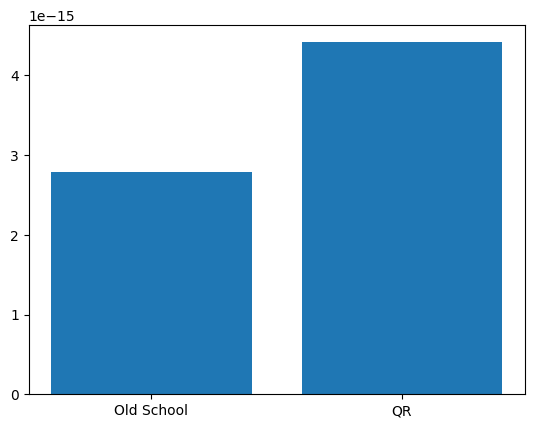

In [20]:
plt.bar(["Old School", "QR"], [old_err, qr_err])

In [ ]:
iterations = 100
matrix_sizes = [5, 30, 100]
results = np.zeros((2*len(matrix_sizes), iterations))
for m_idx, matrix_size in enumerate(matrix_sizes):
    for i in range(iterations):
        M = np.random.default_rng().random((matrix_size, matrix_size))

        old_inv = old_school_inv(M)

        Q, R = np.linalg.qr(M)
        R_inv = np.linalg.inv(R)
        qr_inv = R_inv @ Q.T

        results[m_idx*2, i] = np.linalg.norm(M @ old_inv - np.eye(matrix_size,matrix_size))
        results[m_idx*2+1, i] = np.linalg.norm(M @ qr_inv - np.eye(matrix_size,matrix_size))


In [ ]:
results

In [ ]:
fig, axes = plt.subplots(1, len(matrix_sizes), figsize=(10, 5))
for m_idx, matrix_size in enumerate(matrix_sizes):
    axes[m_idx].set_title(f"Matrix size {matrix_size}x{matrix_size}")
    axes[m_idx].bar(["Old School", "QR"],[results[m_idx*2].mean(), results[m_idx*2+1].mean()])
    axes[m_idx].scatter(x=np.zeros(iterations),y=results[m_idx*2])
    axes[m_idx].scatter(x=1 + np.zeros(iterations),y=results[m_idx*2+1])
plt.tight_layout()

# Exercise 9-6

- All singular values (and the eigen values) of a square orthogonal matrix are 1
- They have an induced 2-norm of 1 (the induced norm is the largest singular value) and they have a Frobenius norm of $M$
- Because the Frobenius norm equals the square root of the sum of the squared singular values
- Create an $M \times M$ orthogonal matrix as the QR decomposition of a random matrix
- Compute it's induced 2-norm using `np.linalg.norm`
- Compute it's Frobenius norm using equation in Ch 6, divided by the square root of $M$
- Confirm that both quantities are 1
- Next explore the meaning of induced norm using matrix-vector multiplication
- Create a random M-element column vector v
- compute the norms of v and Qv
- These norms should equal each other

In [ ]:
M_size = 5
Q, _ = np.linalg.qr(np.random.default_rng().random((M_size, M_size)))
Q

In [ ]:
# this is one because the largest singular norm in an orthogonal matrix is 1
np.linalg.norm(Q, 2)

In [ ]:
# manually find the frobenius norm
frob_norm = 0
for i in range(M_size):
    for j in range(M_size):
        frob_norm += Q[i][j]**2
np.sqrt(frob_norm) / np.sqrt(M_size)

In [ ]:
v = np.random.default_rng().random((M_size, 1))
v

In [ ]:
np.linalg.norm(v)

In [ ]:
# We would expect this norm to equal the norm of 'v' given the Q matrix all has norms of 1
np.linalg.norm(Q @ v)

# Exercise 9-7
- Highlight a feature of $R$ matrix that is relevant for understanding how to use QR to implement least squares
- When $A$ is tall and full column-rank, the first N rows of $R$ are upper-triangular, whereas rows N + 1 through M are zeros
- Confirm by using a random 10x4 matrix
- Do the complete QR decomposition
- $R$ is not invertable because it's nonsquare
- However the submatrix comprising the first N rows is square and full-rank, thus has a full inverse
- and the tall $R$ has a pseuodinverse
- Compute both inveres and confirm that the full inverse of hte first N rows of R equals the first N columns of the pseudoinverse of the tall R

In [ ]:
n, m = 10, 4
Q, R = np.linalg.qr(np.random.default_rng().random((n, m)), "complete")
R

In [ ]:
R_sub = R[:4,:]
R_sub

In [ ]:
R_sub_inv = np.linalg.inv(R_sub)
R_sub_inv

In [ ]:
R_sub_inv @ R_sub

In [ ]:
R_pinv = np.linalg.pinv(R)
R_pinv

In [ ]:
# if we find the distance between the two inverses we see that it's ~0
np.linalg.norm(R_pinv[:,:m] - R_sub_inv)